In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# importing data from google drive
penguins_data = pd.read_csv("/content/drive/MyDrive/ML datasets/penguins.csv")

In [3]:
# removing rows with missing values
penguins_data = penguins_data.dropna()

In [4]:
# defining target and feature variables
x = penguins_data.drop('species', axis = 1)
y = penguins_data['species']

# encoding the categorical variables
x = pd.get_dummies(x, drop_first = True)

In [5]:
# splitting training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x ,y, test_size = 0.2, random_state = 524)

In [6]:
# Logistics Regression model

lm = LogisticRegression()
lm.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [7]:
# model evaluation

# predicting
y_pred = lm.predict(x_test)

# accuracy of the model predictions
print('accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        24
   Chinstrap       1.00      1.00      1.00        15
      Gentoo       1.00      1.00      1.00        28

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



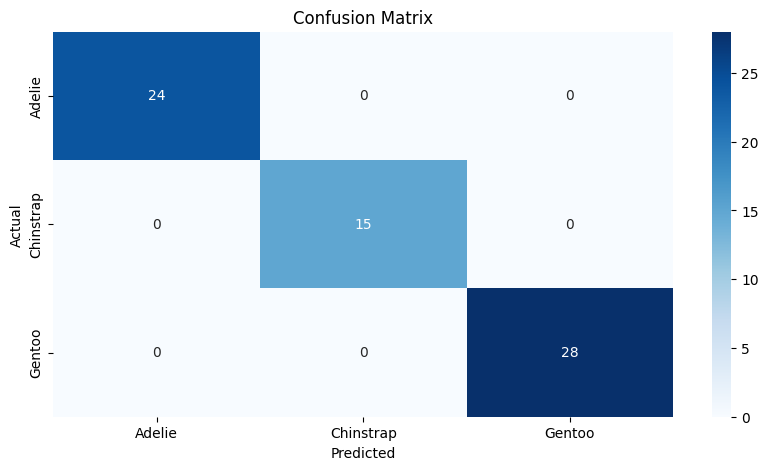

In [8]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10, 5))
sns.heatmap(cm, annot = True, fmt ="d", cmap = "Blues",
    xticklabels = lm.classes_,
    yticklabels = lm.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()